# Brain Tumor Detection – CNN from Scratch
This notebook builds and trains a custom CNN on the brain tumor dataset.

## Check the device that runs the model

In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

I0000 00:00:1778035919.396309   16752 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778035919.437977   16752 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778035920.659225   16752 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Test Data Generator (unseen data)

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    '../data/Testing',          # because notebook is inside 'notebooks/'
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1600 images belonging to 4 classes.


## 2. Training & Validation Generators (from Training/ folder)

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam 

# Common seed for reproducible split
SEED = 42

# Training generator with only horizontal flip (no rotation/shift/zoom)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1, 
    validation_split=0.2
)

# Validation generator – only rescale, no augmentation (uses subset='validation')
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2           # ← required for subset filtering
)

train_generator = train_datagen.flow_from_directory(
    '../data/Training',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    '../data/Training',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

print("Training/validation generators ready (training uses augmentation)")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Training/validation generators ready (training uses augmentation)
Training samples: 4480
Validation samples: 1120


## 3. Compute custom class weights, as of now increase the weights for glioma

In [4]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get all true labels from the training generator (these are integers 0..3)
y_train = train_generator.classes

# Compute balanced class weights
# Manual class weights: boost glioma (class 0)
class_weight = {0: 1.5, 1: 1, 2: 1.0, 3: 1.0}
print("Class weights:", class_weight)

Class weights: {0: 1.5, 1: 1, 2: 1.0, 3: 1.0}


## 4. Build and Compile the CNN Model

In [5]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'      # Suppresses info/warning logs
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'     # Suppresses oneDNN custom operations message
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, GlobalAveragePooling2D, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2), 
    #GlobalAveragePooling2D(),       horrible model
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),   # half of default
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/home/alexei/brain-tumor-detection-model/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778035921.999867   16752 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2143 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,060 (24.86 MB)

 Trainable params: 6,517,060 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Callbacks – Early Stopping and Model Checkpoint

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

os.makedirs('models', exist_ok=True)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('models/scratch_model.keras', monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

## 6. Train the Model

In [7]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1,
    class_weight=class_weight
)

Epoch 1/50


I0000 00:00:1778035922.897438   16752 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1778035923.779526   16906 service.cc:153] XLA service 0x7bfb900152d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778035923.779548   16906 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778035923.810219   16906 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778035924.006600   16906 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778035924.040216   16906 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2083__.44


  3/140 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.3090 - loss: 1.6385 

I0000 00:00:1778035930.558998   16906 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.6163 - loss: 0.9991 - val_accuracy: 0.7473 - val_loss: 0.6128 - learning_rate: 5.0000e-04
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.7554 - loss: 0.6888 - val_accuracy: 0.7536 - val_loss: 0.6178 - learning_rate: 5.0000e-04
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.7987 - loss: 0.5689 - val_accuracy: 0.8009 - val_loss: 0.4908 - learning_rate: 5.0000e-04
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.8221 - loss: 0.5006 - val_accuracy: 0.8277 - val_loss: 0.4703 - learning_rate: 5.0000e-04
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 90ms/step - accuracy: 0.8359 - loss: 0.4579 - val_accuracy: 0.7714 - val_loss: 0.6300 - learning_rate: 5.0000e-04
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.8527 - loss: 0.4044 - val_accuracy: 0.8196 - val_loss: 0.5222 - learning_rate: 5.0000e-04
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accura

## 7. Evaluation on the Test Set

In [8]:
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"Brain Scan CNN - Test accuracy: {test_acc:.4f}")

Brain Scan CNN - Test accuracy: 0.9125


## 8. Evaluate the Best Saved Model (Checkpoint)

In [9]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # Suppresses all logs below ERROR
from tensorflow.keras.models import load_model
best = load_model('models/scratch_model.keras')
test_loss, test_acc = best.evaluate(test_generator, verbose=0)
print(f"Best checkpoint model test accuracy: {test_acc:.4f}")

Best checkpoint model test accuracy: 0.9112


## 9. Save Training History to JSON

In [10]:
import json
history_dict = {
    'accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'],
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss'],
    'best_val_acc': max(history.history['val_accuracy']),
    'best_test_acc': test_acc  # from above
}
with open('scratch_history.json', 'w') as f:
    json.dump(history_dict, f)

## 10. Visualise Training History (Accuracy & Loss)

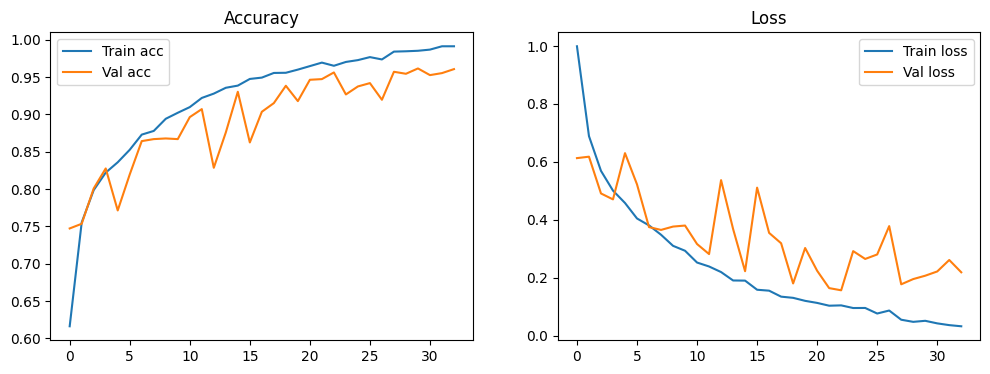

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss')
plt.legend()
plt.show()

## 11. Compare new to backed up model

In [12]:
from tensorflow.keras.models import load_model
backup_model = load_model('models/scratch_model_backup.keras')
new_model = load_model('models/scratch_model.keras')
print("Backup test accuracy:", backup_model.evaluate(test_generator, verbose=0)[1])
print("New model test accuracy:", new_model.evaluate(test_generator, verbose=0)[1])

Backup test accuracy: 0.5568749904632568
New model test accuracy: 0.9112499952316284


## 12. Compare the weight differences to affirm the models are different

In [13]:
import numpy as np
diff = np.max(np.abs(backup_model.get_weights()[0] - new_model.get_weights()[0]))
print(f"Maximum weight difference: {diff}")

Maximum weight difference: 0.3374674916267395


## 13. Generate a confusion matrix, classification report

In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
y_pred = best.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion matrix
print(confusion_matrix(y_true, y_pred_classes))

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.80      0.88       400
  meningioma       0.95      0.85      0.90       400
     notumor       0.80      1.00      0.89       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.91      1600
weighted avg       0.92      0.91      0.91      1600

[[319  17  61   3]
 [  8 342  40  10]
 [  0   0 400   0]
 [  1   1   1 397]]


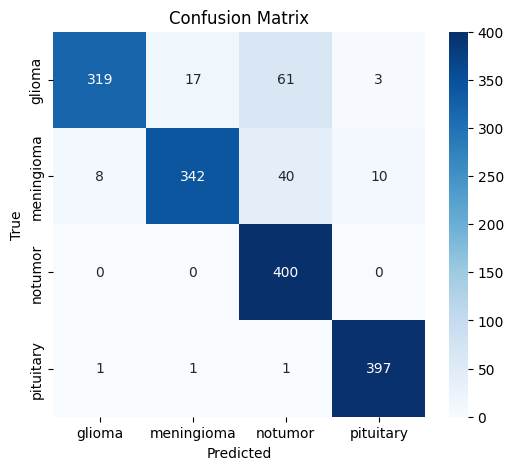

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## 14. Backup the last produced model

In [16]:
import shutil
import os

# Paths (assuming notebook is in notebooks/ folder)
src = 'models/scratch_model.keras'
dst = 'models/scratch_model_backup.keras'

if os.path.exists(src):
    shutil.copy(src, dst)
    print(f"Backed up {src} to {dst}")
else:
    print(f"Source file {src} not found. Nothing copied.")

Backed up models/scratch_model.keras to models/scratch_model_backup.keras
